In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from decimal import Decimal
import os

matplotlib.rcParams['figure.figsize'] = [15, 15]
matplotlib.rcParams.update({'font.size': 32})

pure_fitness = '/home/spsalmon/Learning_accelerates_aging/landscapes/fitness_landscape/output/gla_landscapes_gmax/csv/fitness_increasing_fertility.csv'
fitness_difference = '/home/spsalmon/Learning_accelerates_aging/landscapes/fitness_landscape/output/gla_landscapes_gmax/csv/fitness_difference_increasing_fertility.csv'
output_dir = '/home/spsalmon/Learning_accelerates_aging/landscapes/fitness_landscape/output/gla_landscapes_gmax/plots/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
fitness_difference_csv = pd.read_csv(fitness_difference)
pure_fitness_csv = pd.read_csv(pure_fitness)
landscape_type = os.path.basename(fitness_difference).split('.')[0]
landscape_type = landscape_type.split('fitness_difference_')[1]

print(landscape_type)

print(fitness_difference_csv)
# print the row where fitness_difference is maximum

print(fitness_difference_csv.loc[fitness_difference_csv['fitness_difference'].idxmax()])

# sort the dataframe by b and lmax

fitness_difference_csv = fitness_difference_csv.sort_values(by=['b', 'gmax'])
pure_fitness_csv = pure_fitness_csv.sort_values(by=['b', 'gmax'])

increasing_fertility
             b      gmax  fitness_difference
0      0.00001  0.000000        3.468952e-08
1      0.00001  0.001005        3.469594e-08
2      0.00001  0.002010        3.470236e-08
3      0.00001  0.003015        3.470879e-08
4      0.00001  0.004020        3.471522e-08
...        ...       ...                 ...
39995  0.14000  0.195980        4.742563e-03
39996  0.14000  0.196985        4.727445e-03
39997  0.14000  0.197990        4.712332e-03
39998  0.14000  0.198995        4.697223e-03
39999  0.14000  0.200000        4.682119e-03

[40000 rows x 3 columns]
b                     0.140000
gmax                  0.055276
fitness_difference    0.006588
Name: 39855, dtype: float64


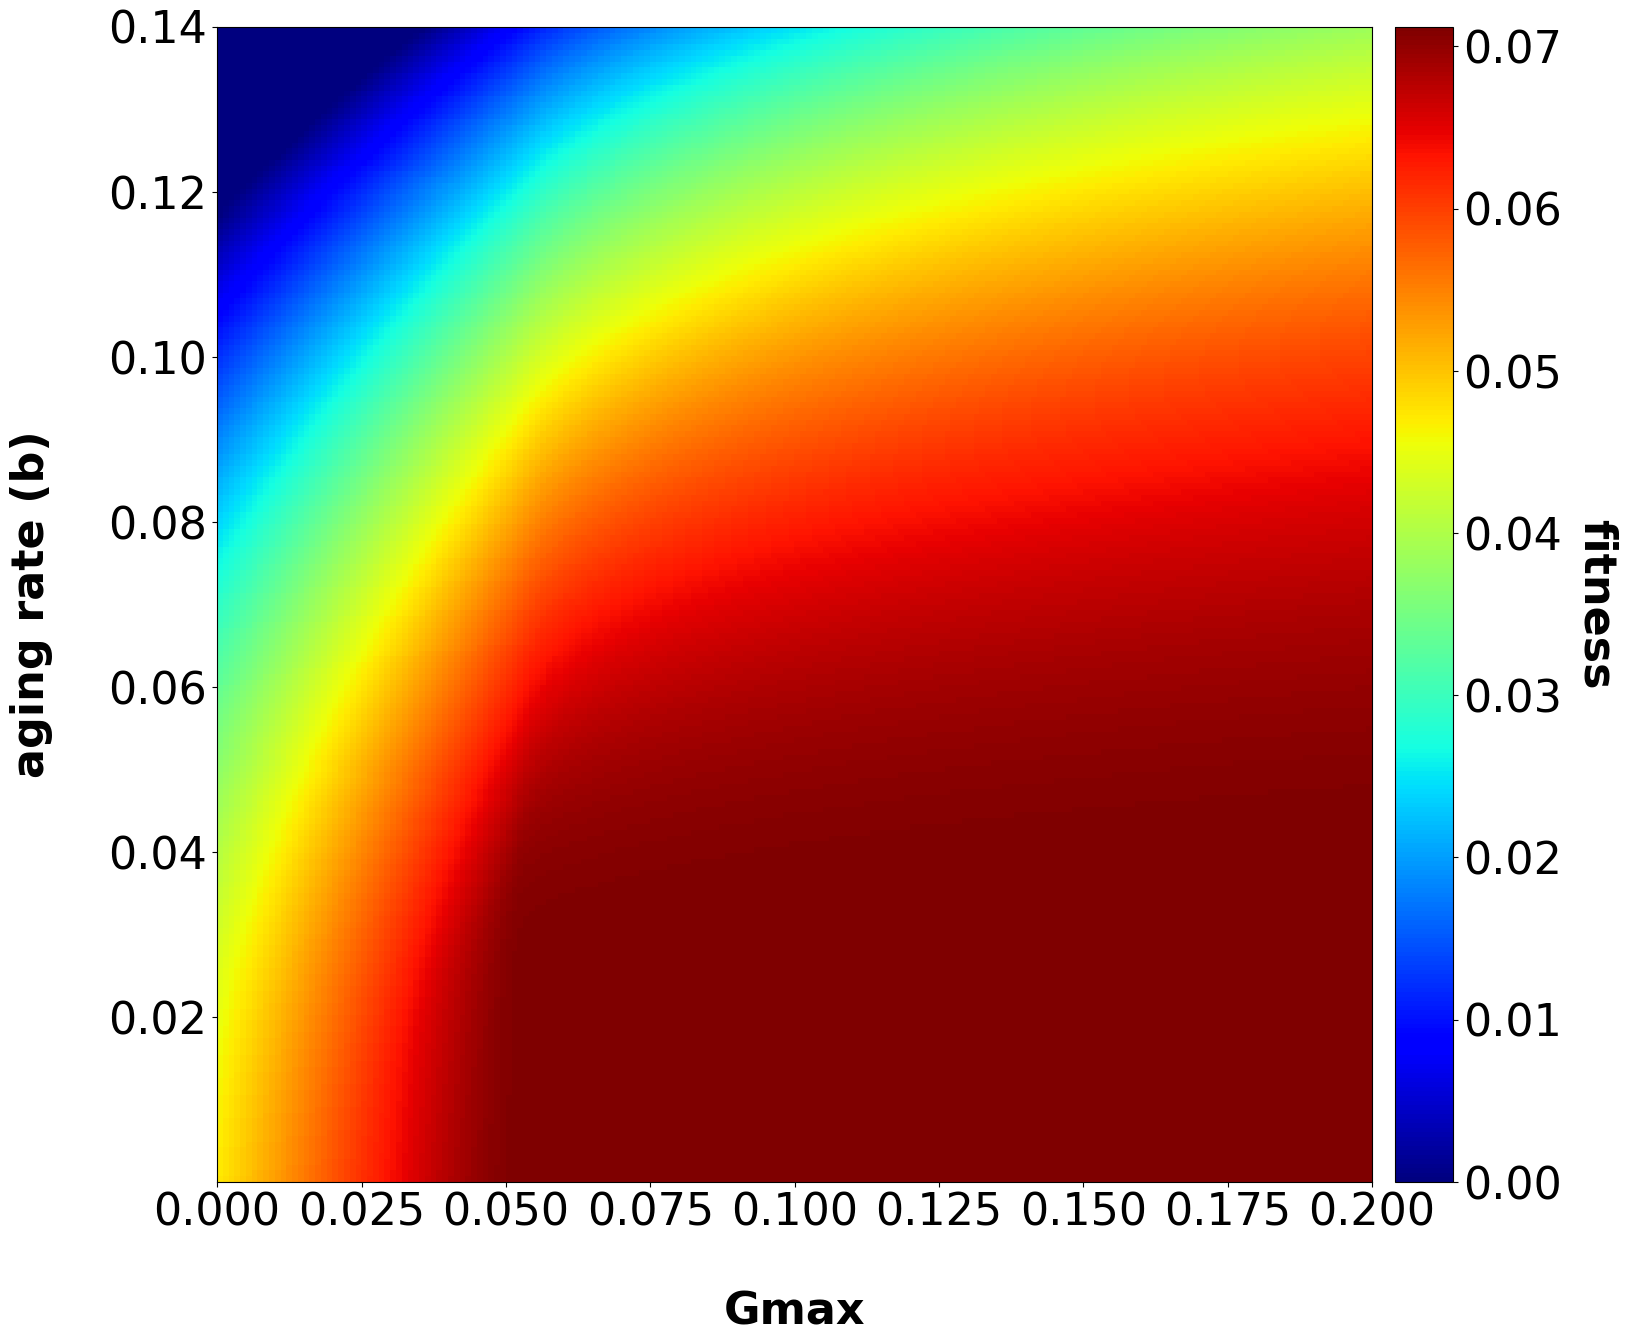

In [15]:
b = fitness_difference_csv['b']
gmax = fitness_difference_csv['gmax']
fitness = pure_fitness_csv['fitness']

grid_size = int(np.sqrt(len(b)))

b = np.array(b).reshape(grid_size, grid_size)
gmax = np.array(gmax).reshape(grid_size, grid_size)
fitness = np.array(fitness).reshape(grid_size, grid_size)

fig = plt.figure()
ax = plt.axes()
extent = [gmax.min(), gmax.max(), b.min(), b.max()]
im = ax.imshow(fitness, cmap="jet", interpolation="none", origin="lower", extent=extent, aspect = abs((extent[1]-extent[0])/(extent[3]-extent[2])))
axins = inset_axes(ax, width = "5%", height = "100%", loc = 'lower left',
                   bbox_to_anchor = (1.02, 0., 1, 1), bbox_transform = ax.transAxes,
                   borderpad = 0)
cbar = fig.colorbar(im, cax = axins)
# cbar.ax.tick_params(labelsize=25)
cbar.set_label('fitness', rotation=270, labelpad = 40, fontweight="bold")


ax.set_ylabel("aging rate (b)", fontweight="bold", labelpad=40)
ax.set_xlabel("Gmax", fontweight="bold", labelpad=40)
# ax.set_title("Selection Pressure", fontweight="bold", fontsize=35, pad=40)

ax.tick_params(axis="x") 
ax.tick_params(axis="y") 
plt.savefig(f"{output_dir}/fitness_{landscape_type}", bbox_inches='tight', dpi=300)
plt.show()

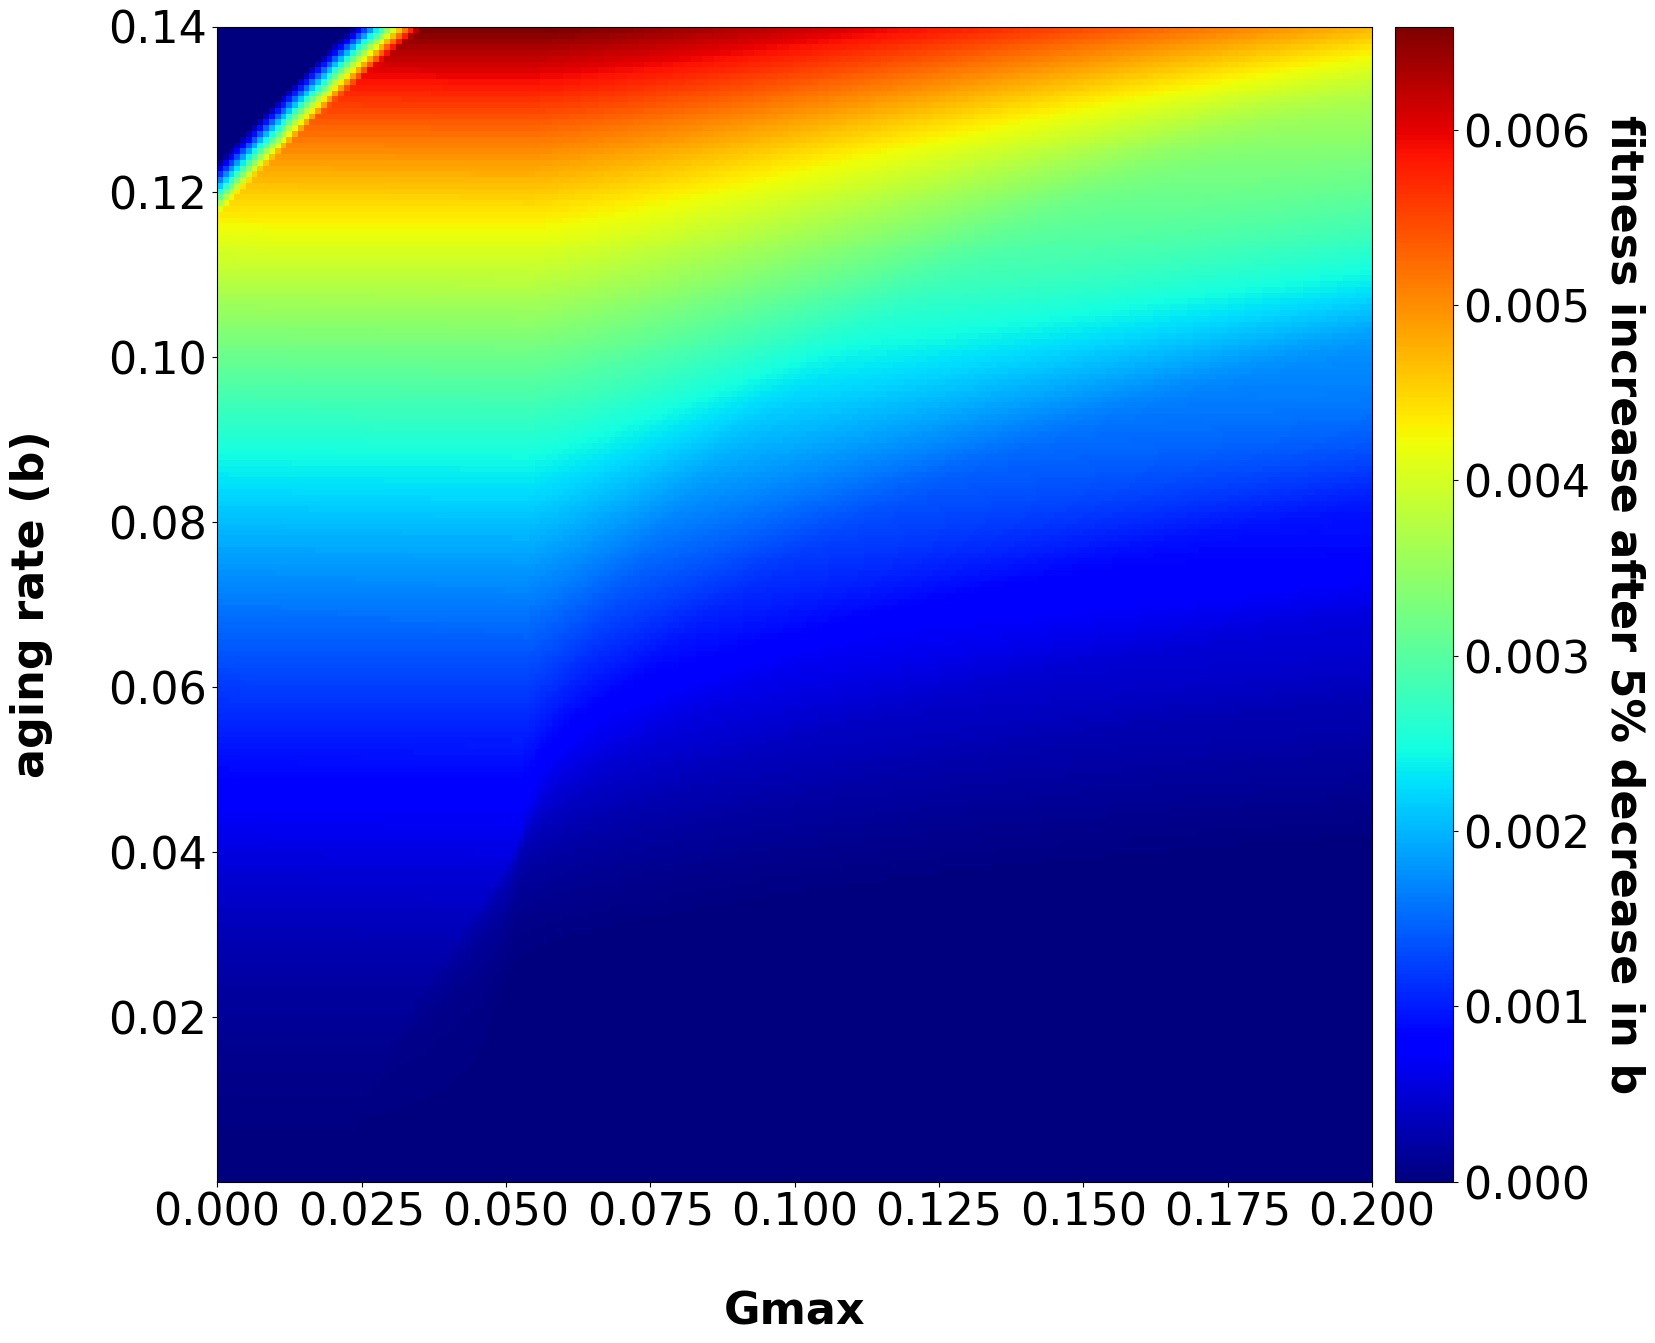

In [16]:
b = fitness_difference_csv['b']
gmax = fitness_difference_csv['gmax']
fitness_difference = fitness_difference_csv['fitness_difference']

grid_size = int(np.sqrt(len(b)))

b = np.array(b).reshape(grid_size, grid_size)
gmax = np.array(gmax).reshape(grid_size, grid_size)
fitness_difference = np.array(fitness_difference).reshape(grid_size, grid_size)

fig = plt.figure()
ax = plt.axes()
extent = [gmax.min(), gmax.max(), b.min(), b.max()]
im = ax.imshow(fitness_difference, cmap="jet", interpolation="none", origin="lower", extent=extent, aspect = abs((extent[1]-extent[0])/(extent[3]-extent[2])))
axins = inset_axes(ax, width = "5%", height = "100%", loc = 'lower left',
                   bbox_to_anchor = (1.02, 0., 1, 1), bbox_transform = ax.transAxes,
                   borderpad = 0)
cbar = fig.colorbar(im, cax = axins)
# cbar.ax.tick_params(labelsize=25)
cbar.set_label('fitness increase after 5% decrease in b', rotation=270, labelpad = 40, fontweight="bold")


ax.set_ylabel("aging rate (b)", fontweight="bold", labelpad=40)
ax.set_xlabel("Gmax", fontweight="bold", labelpad=40)
# ax.set_title("Selection Pressure", fontweight="bold", fontsize=35, pad=40)

ax.tick_params(axis="x") 
ax.tick_params(axis="y") 
plt.savefig(f"{output_dir}/selection_pressure_{landscape_type}", bbox_inches='tight', dpi=300)
plt.show()


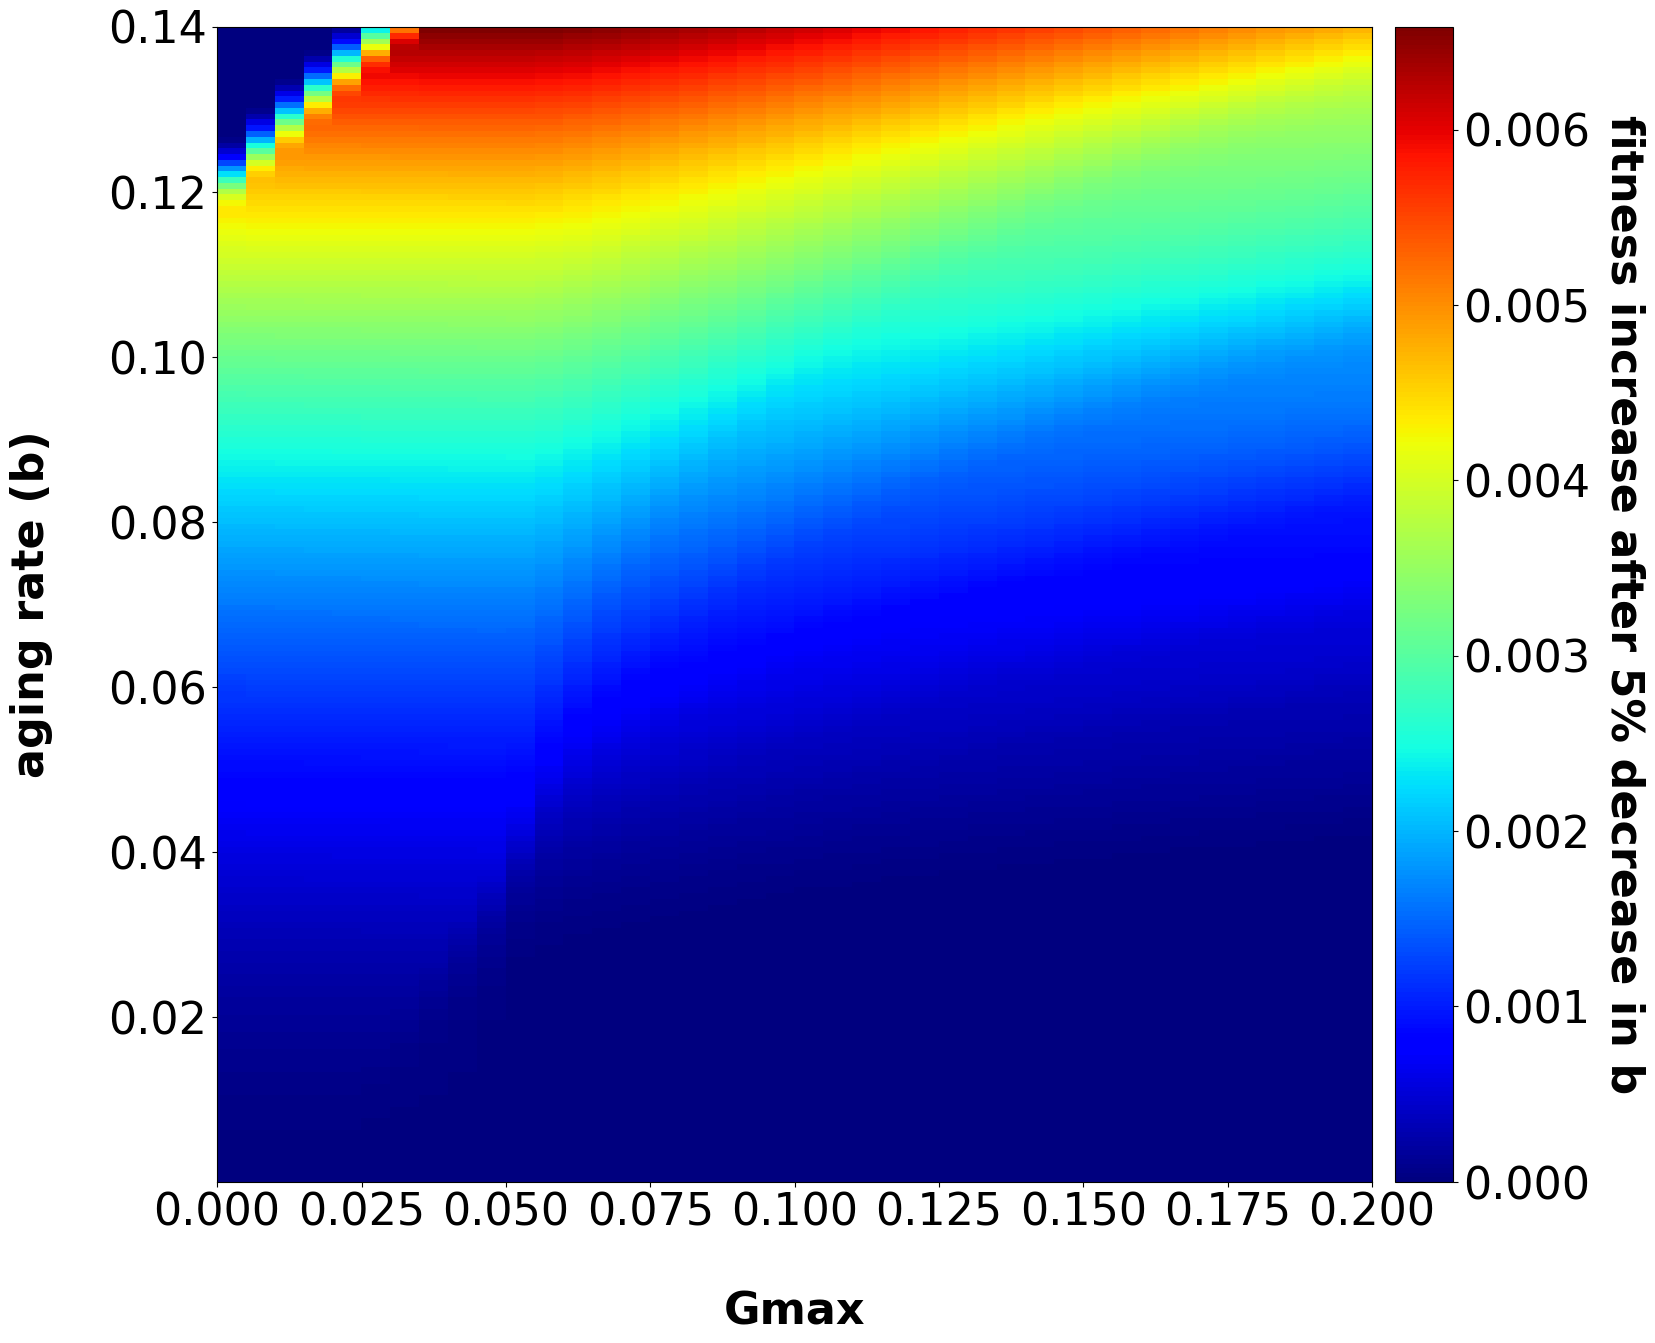

In [17]:
# # Compute the difference to the first value in a line
# diff = np.zeros_like(fitness_difference)
# for i, row in enumerate(fitness_difference):
#     r = [(x-row[0]) for x in row]
#     diff[i, :] = r

# # Save max and min differences
# max_diff = np.max(diff)
# min_diff = np.min(diff)

# # Normalize the differences (this makes the plot way prettier)
# for i in range(diff.shape[0]):
#     for j in range(diff.shape[1]):
#         y = diff[i, j]
#         if y > 0:
#             diff[i, j] = y/max_diff
#         if y < 0:
#             diff[i, j] = -(y/min_diff)

# Compute the a rolling mean of the fitness on each row

window_size = 5
fitness_difference_rolling_mean = np.zeros((fitness.shape[0], fitness.shape[1]//window_size))
for j in range(fitness.shape[0]):
    for i in range(fitness.shape[1]//window_size):
        fitness_difference_rolling_mean[j, i] = np.mean(fitness_difference[j, i*window_size:i*window_size+window_size])

# Plot the rolling mean
fig = plt.figure()
ax = plt.axes()
extent = [gmax.min(), gmax.max(), b.min(), b.max()]
im = ax.imshow(fitness_difference_rolling_mean, cmap="jet", interpolation="none", origin="lower", extent=extent, aspect = abs((extent[1]-extent[0])/(extent[3]-extent[2])))
axins = inset_axes(ax, width = "5%", height = "100%", loc = 'lower left',
                   bbox_to_anchor = (1.02, 0., 1, 1), bbox_transform = ax.transAxes,
                   borderpad = 0)
cbar = fig.colorbar(im, cax = axins)
# cbar.ax.tick_params(labelsize=25)
cbar.set_label('fitness increase after 5% decrease in b', rotation=270, labelpad = 40, fontweight="bold")


ax.set_ylabel("aging rate (b)", fontweight="bold", labelpad=40)
ax.set_xlabel("Gmax", fontweight="bold", labelpad=40)
# ax.set_title("Selection Pressure", fontweight="bold", fontsize=35, pad=40)

ax.tick_params(axis="x") 
ax.tick_params(axis="y") 
# plt.savefig(f"./output/gmax_fitness_landscapes/plots/selection_pressure_{landscape_type}.png", bbox_inches='tight')
plt.show()


# Compute the difference of each point of the rolling mean to the previous one in the same row

diff = np.zeros_like(fitness_difference_rolling_mean)


for i in range(fitness_difference_rolling_mean.shape[0]):
    for j in range(fitness_difference_rolling_mean.shape[1]):
        if j == 0:
            diff[i, :] = 0
        else:
            diff[i, j] = fitness_difference_rolling_mean[i, j] - fitness_difference_rolling_mean[i, j-1]

# Save max and min differences
max_diff = np.max(diff)
min_diff = np.min(diff)

# Normalize the differences (this makes the plot way prettier)
for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        y = diff[i, j]
        if y > 0:
            diff[i, j] = y/max_diff
        if y < 0:
            diff[i, j] = -(y/min_diff)

# remove the first column of the difference
diff = diff[:, 1:]

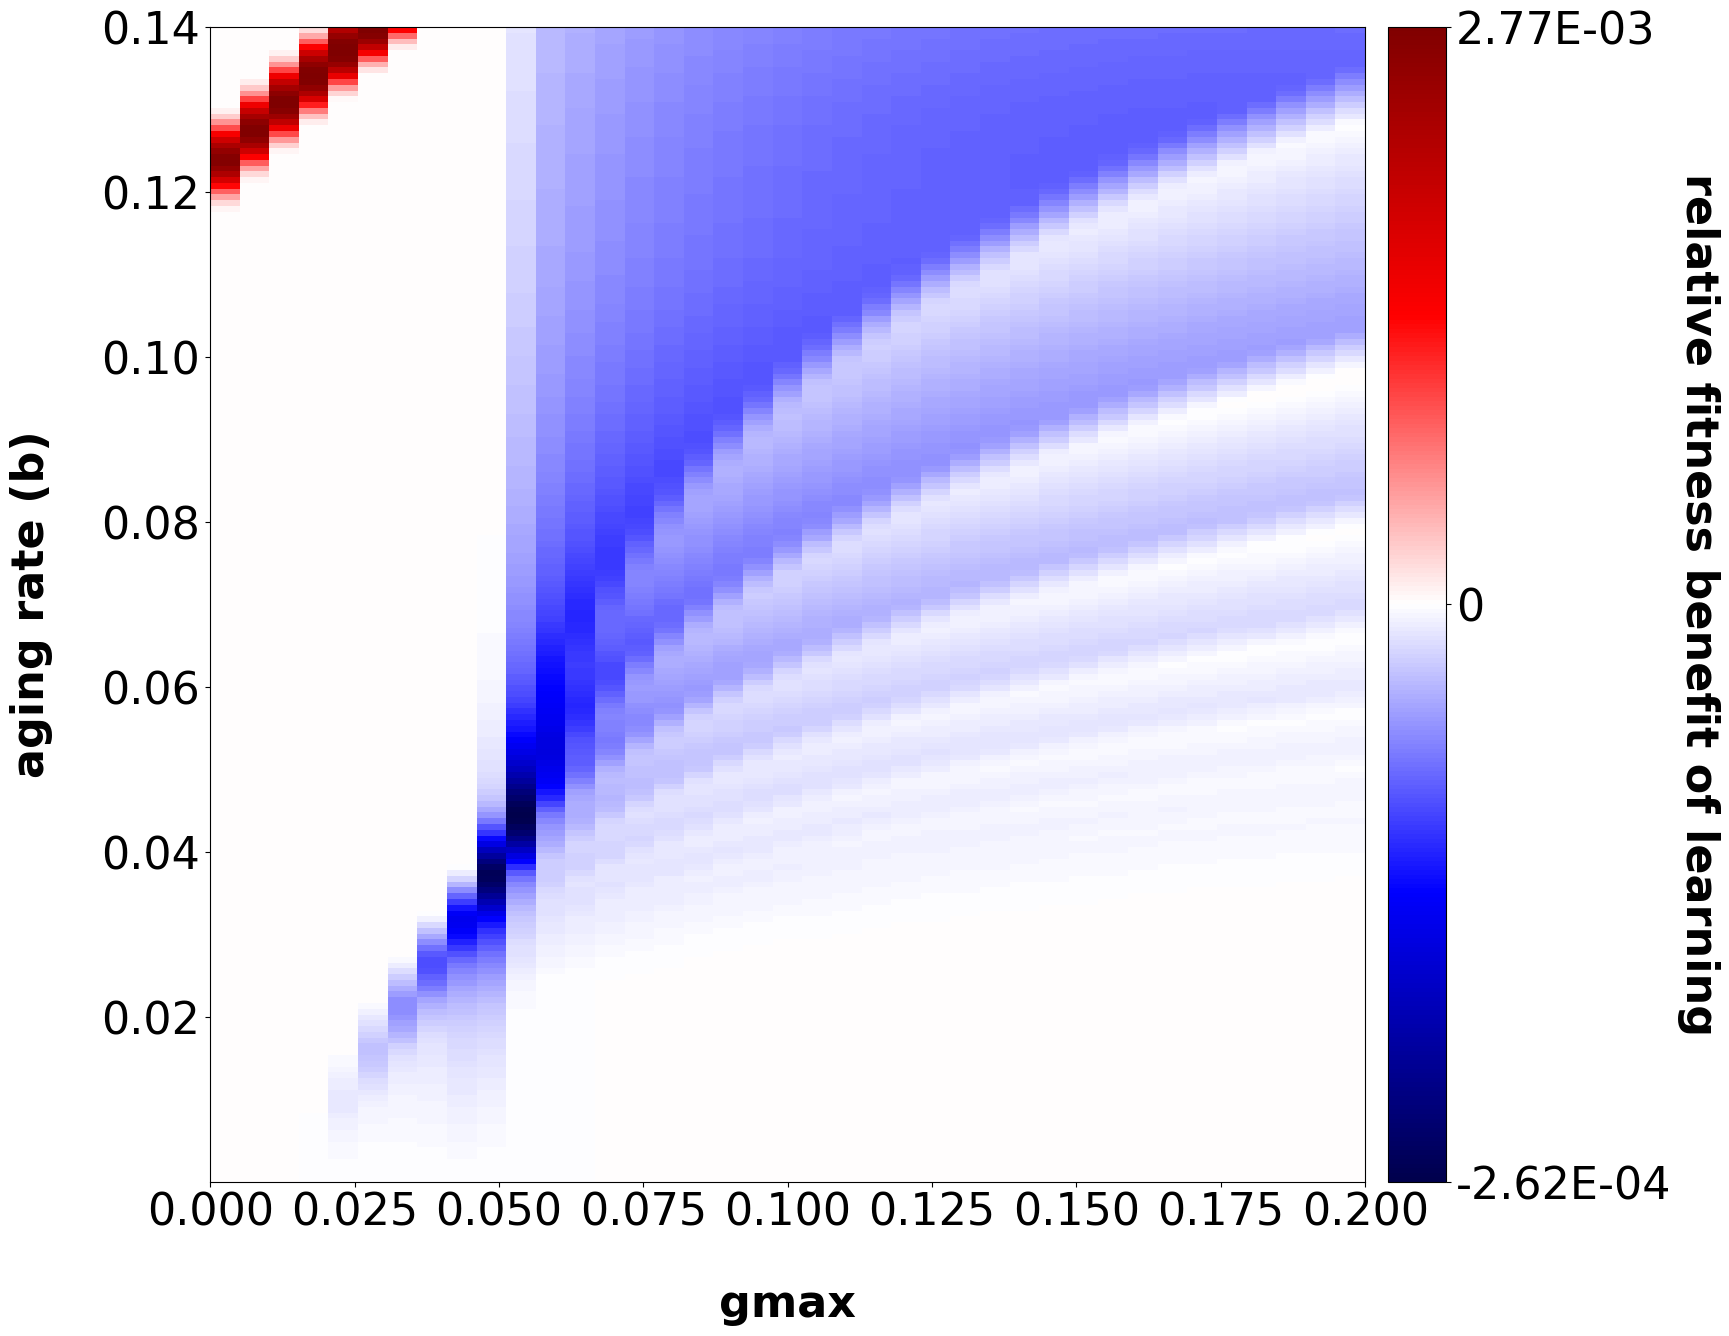

In [18]:
fig = plt.figure()
ax = plt.axes()

im = ax.imshow(diff, cmap="seismic", interpolation="none", origin="lower", extent=extent, aspect = abs((extent[1]-extent[0])/(extent[3]-extent[2])))

axins = inset_axes(ax, width = "5%", height = "100%", loc = 'lower left',
                   bbox_to_anchor = (1.02, 0., 1, 1), bbox_transform = ax.transAxes,
                   borderpad = 0)

cbar = fig.colorbar(im, cax = axins, ticks = [-1, 0, 1])
cbar.ax.set_yticklabels(['%.2E' % Decimal(min_diff), '0', '%.2E' % Decimal(max_diff)])
cbar.set_label('relative fitness benefit of learning', rotation=270, labelpad = 35, fontweight="bold")


ax.set_ylabel("aging rate (b)", fontweight="bold", labelpad=35)
ax.set_xlabel("gmax", fontweight="bold", labelpad=35)

plt.savefig(f"{output_dir}/mean_fitness_benefit_of_growth_{landscape_type}", bbox_inches='tight', dpi=300)
# ax.scatter(0, final_value_without_learning, marker = 'x', linewidths=20)
# ax.scatter(0.1, final_value_with_learning, marker = "x", linewidths=20)


plt.show()

In [19]:
# # Plot the evolution trajectory on top
# simulation_learning_df = pd.read_csv('/home/spsalmon/agent_based_simulation/simulation_results/plateau_brass_polynomial_equal_both_random_mating_with_learning_non_reproducing_removed_0.15.csv')
# average_learning = simulation_learning_df.groupby('time')[['mean_b', 'mean_lmax']].mean().reset_index()

# # simulation_no_learning_df = pd.read_csv('/home/spsalmon/agent_based_simulation/simulation_results/plateau_brass_polynomial_equal_both_random_mating_without_learning_non_reproducing_removed_0.15.csv')
# # average_no_learning = simulation_no_learning_df.groupby('time')[['mean_b', 'mean_lmax']].mean().reset_index()

# fig = plt.figure()
# ax = plt.axes()

# im = ax.imshow(diff, cmap="seismic", interpolation="none", origin="lower", extent=extent, aspect = abs((extent[1]-extent[0])/(extent[3]-extent[2])))
# # ax.plot(average_learning['mean_lmax'], average_learning['mean_b'], linewidth=2, color="yellow")
# ax.arrow(average_learning['mean_lmax'].iloc[0], average_learning['mean_b'].iloc[0], average_learning['mean_lmax'].iloc[-1]-average_learning['mean_lmax'].iloc[0], average_learning['mean_b'].iloc[-1]-average_learning['mean_b'].iloc[0], head_width=0.0008, head_length=0.001, color="yellow", linewidth=2, width=0.000002)

# axins = inset_axes(ax, width = "5%", height = "100%", loc = 'lower left',
#                    bbox_to_anchor = (1.02, 0., 1, 1), bbox_transform = ax.transAxes,
#                    borderpad = 0)

# cbar = fig.colorbar(im, cax = axins, ticks = [-1, 0, 1])
# cbar.ax.set_yticklabels(['%.2E' % Decimal(min_diff), '0', '%.2E' % Decimal(max_diff)])
# cbar.set_label('relative fitness benefit of learning', rotation=270, labelpad = 35, fontweight="bold")


# ax.set_ylabel("aging rate (b)", fontweight="bold", labelpad=35)
# ax.set_xlabel("Lmax", fontweight="bold", labelpad=35)

# plt.show()
